# 09 · Confirmación externa de la v4 en SVDB

**Por qué otra base.** La v4 (morfología relativa al paciente) mejoró mucho en DS1, pero ahí se
eligió: hace falta confirmarla donde no se decidió nada. DS2 se gastó en la Fase 5 e INCART se usó
para comparar v1 con v2, así que la confirmación va sobre una tercera base.

**SVDB** (MIT-BIH Supraventricular Arrhythmia Database): 78 registros de 30 minutos, **128 Hz**,
canales llamados **ECG1/ECG2** sin identificar qué derivación son. Es el cambio de dominio más
fuerte de los tres. Y tiene **6.6 % de latidos S**, contra 1.85 % en DS1: es la prueba real para
la clase que sigue floja.

**Fijado antes de mirar los resultados:**

1. **Tarea de 3 clases (N/S/V)**, porque v3 y v4 no emiten F. A los modelos de 4 clases se les
   restringe la salida a esas tres, así todos se miden sobre los mismos latidos.
2. **Comparación primaria: v4 contra v3.** Son idénticos salvo por las features relativas.
3. **Prueba pareada por paciente** (Wilcoxon), porque en INCART el agregado escondía que la mejora
   no era pareja.
4. Se espera que todos rindan peor que en MIT-BIH por el cambio de canal y de población.
5. **Ningún modelo se toca después de ver esto.** SVDB queda gastada.

> Proyecto educativo y de investigación. No es un dispositivo médico.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image
from scipy.stats import wilcoxon

from ecg import config
from ecg.evaluate import per_class_metrics, per_record_metrics, summary
from ecg.evaluate_external import DS1_RR_RANGE, per_record_heart_rate, predict_all
from ecg.segment import load_split

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.precision", 3)
FIG_DIR = config.REPORTS_DIR / "figures"
CLASSES = ["N", "S", "V"]
MODELOS = ["v1_rr_absoluto", "v2_rr_normalizado", "v3_3clases", "v4_morfologia_relativa"]

svdb = load_split("svdb")
en_tarea = np.isin(svdb["y"], CLASSES)
svdb = {k: v[en_tarea] for k, v in svdb.items()}
y, records, symbols = svdb["y"], svdb["record"], svdb["symbol"]
preds = predict_all(svdb, with_cnn=False, models=MODELOS, classes=CLASSES)
print(f"SVDB: {len(y)} latidos de {len(np.unique(records))} pacientes "
      f"({int((~en_tarea).sum())} latidos F excluidos)")

SVDB: 184324 latidos de 78 pacientes (23 latidos F excluidos)


## 1. Qué tan distinta es SVDB

In [2]:
ds1 = load_split("ds1")
comparacion = pd.DataFrame({
    "DS1 (entrenamiento)": {
        "pacientes": len(np.unique(ds1["record"])), "latidos": len(ds1["y"]),
        "% de latidos S": round(100 * (ds1["y"] == "S").mean(), 2),
        "% de latidos V": round(100 * (ds1["y"] == "V").mean(), 2),
        "muestreo (Hz)": 360, "canal": "MLII"},
    "SVDB": {
        "pacientes": len(np.unique(records)), "latidos": len(y),
        "% de latidos S": round(100 * (y == "S").mean(), 2),
        "% de latidos V": round(100 * (y == "V").mean(), 2),
        "muestreo (Hz)": 128, "canal": "ECG1 (sin identificar)"},
})
comparacion

,DS1 (entrenamiento),SVDB
pacientes,22,78
latidos,50969,184324
% de latidos S,1.85,6.62
% de latidos V,7.43,5.39
muestreo (Hz),360,128
canal,MLII,ECG1 (sin identificar)


## 2. Resultado: ¿se confirma la v4?

In [3]:
filas = {}
for nombre, p in preds.items():
    s = summary(y, p, CLASSES)
    filas[nombre] = {**{k: v for k, v in s.items() if v is not None},
                     "V→N": int(((y == "V") & (p == "N")).sum()),
                     "falsas alarmas sobre N": int(((y == "N") & (p != "N")).sum()),
                     "errores": int((y != p).sum())}
tabla = pd.DataFrame(filas).T
tabla[["macro_f1", "N_F1", "S_Se", "S_+P", "S_F1", "V_Se", "V_+P", "V_F1",
       "V→N", "falsas alarmas sobre N", "errores"]].round(3)

,macro_f1,N_F1,S_Se,S_+P,S_F1,V_Se,V_+P,V_F1,V→N,falsas alarmas sobre N,errores
v1_rr_absoluto,0.596,0.931,0.277,0.440,0.340,0.890,0.365,0.518,749.0,15746.0,25652.0
v2_rr_normalizado,0.621,0.944,0.281,0.588,0.380,0.882,0.388,0.539,868.0,12097.0,22039.0
v3_3clases,0.612,0.941,0.265,0.598,0.367,0.874,0.376,0.526,962.0,12490.0,22702.0
v4_morfologia_relativa,0.698,0.963,0.305,0.618,0.408,0.895,0.607,0.724,780.0,5356.0,14878.0


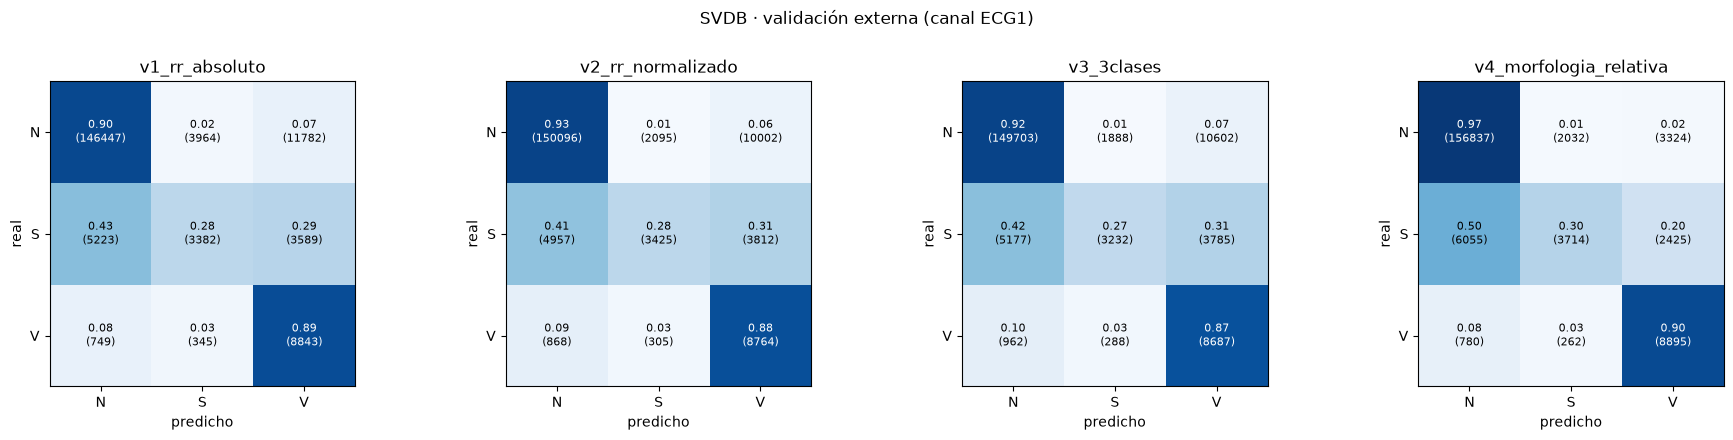

In [4]:
Image(str(FIG_DIR / "svdb_confusion.png"))

**Conclusiones:**

- **La v4 se confirma en pacientes nuevos:** F1 macro **0.612 → 0.698** contra la v3, con
  **34 % menos errores** (22 702 → 14 878). La mejora que se midió en DS1 no era un artefacto de
  haber elegido ahí.
- **El salto está donde se esperaba:** la +P de V pasa de 0.376 a **0.607** y su F1 de 0.526 a
  0.724. Los falsos V bajan de 10 602 a 3 324, un 69 % menos.
- **Acá S también mejora** (F1 0.367 → 0.408), a diferencia de DS1, donde empeoraba. Con 12 194
  latidos S, esta es la medición más confiable de esa clase en todo el proyecto.
- **El orden de las versiones no es el mismo que en DS1:** acá v2 (0.621) le gana levemente a v3
  (0.612), es decir que sacar la clase F costó un poco. La diferencia es chica, pero recuerda que
  cada base ordena distinto a modelos parecidos.
- Como se esperaba, el nivel general es más bajo que en MIT-BIH: cambia el canal (ECG1 sin
  identificar, no MLII) y la población.

## 3. ¿Es sólida la diferencia? Comparación pareada por paciente

In [5]:
por_paciente = pd.DataFrame({
    "lpm": per_record_heart_rate(svdb)["lpm"],
    "latidos": per_record_metrics(y, preds["v3_3clases"], records, CLASSES)["latidos"],
    "err_v3": per_record_metrics(y, preds["v3_3clases"], records, CLASSES)["errores"],
    "err_v4": per_record_metrics(y, preds["v4_morfologia_relativa"], records, CLASSES)["errores"],
})
por_paciente["diferencia"] = por_paciente.err_v4 - por_paciente.err_v3
w = wilcoxon(por_paciente.err_v3, por_paciente.err_v4)
print(f"v4 mejor en {int((por_paciente.diferencia < 0).sum())} de {len(por_paciente)} pacientes · "
      f"v3 mejor en {int((por_paciente.diferencia > 0).sum())} · "
      f"empates {int((por_paciente.diferencia == 0).sum())}")
print(f"Wilcoxon pareado sobre errores por paciente: p = {w.pvalue:.4f}")
print(f"suma de ganancias {int(por_paciente[por_paciente.diferencia < 0].diferencia.sum())} · "
      f"suma de pérdidas +{int(por_paciente[por_paciente.diferencia > 0].diferencia.sum())}")
display(por_paciente.nsmallest(5, "diferencia"))
por_paciente.nlargest(3, "diferencia")

v4 mejor en 47 de 78 pacientes · v3 mejor en 29 · empates 2
Wilcoxon pareado sobre errores por paciente: p = 0.0076
suma de ganancias -8626 · suma de pérdidas +802


,lpm,latidos,err_v3,err_v4,diferencia
record,,,,,
862,75.3,2181,2042,29,-2013
850,61.5,1836,1230,9,-1221
886,74.0,2221,999,14,-985
841,58.7,1849,1095,239,-856
868,110.2,3334,2441,1688,-753


,lpm,latidos,err_v3,err_v4,diferencia
record,,,,,
869,66.1,2159,285,430,145
889,57.3,1707,87,194,107
828,62.4,1911,44,138,94


**Conclusión: esta vez la mejora sí es estadísticamente sólida.**

v4 gana en **47 de 78 pacientes** y la prueba pareada da **p = 0.008**. Es un contraste
importante con la validación de la v2 en INCART, donde el agregado mejoraba pero el test pareado
no era significativo (p = 0.75). Además la asimetría es enorme: las ganancias suman 8 626 errores
y las pérdidas apenas 802, una relación de 10 a 1.

## 4. Cómo cambia la composición de los errores

In [6]:
composicion = {}
for nombre in ["v3_3clases", "v4_morfologia_relativa"]:
    p = preds[nombre]
    composicion[nombre] = pd.Series(
        [f"{a}→{b}" for a, b in zip(y, p) if a != b]).value_counts()
pd.DataFrame(composicion).fillna(0).astype(int)

,v3_3clases,v4_morfologia_relativa
N→S,1888,2032
N→V,10602,3324
S→N,5177,6055
S→V,3785,2425
V→N,962,780
V→S,288,262


**Conclusiones:**

- **El error dominante desaparece:** los N→V caen de 10 602 a 3 324. Es el mismo efecto que en
  DS1: dejar de confundir "latido raro para la población" con "latido raro para este paciente".
- **A cambio, la v4 pierde algunos S** (S→N sube de 5 177 a 6 055). Sigue el patrón conocido: un
  latido supraventricular tiene morfología normal, así que compararlo con la plantilla no ayuda y
  a veces lo empuja hacia N.

## 5. Dónde falla todo: los pacientes con la arritmia como ritmo de base

In [7]:
hr = per_record_heart_rate(svdb)
fuera = hr[~hr.dentro_rango_ds1]
print(f"rango de frecuencias visto en DS1: {60 / DS1_RR_RANGE[1]:.0f} a {60 / DS1_RR_RANGE[0]:.0f} lpm")
detalle = []
for rec in fuera.index:
    m = records == rec
    pc = per_class_metrics(y[m], preds["v4_morfologia_relativa"][m], CLASSES)
    detalle.append({"registro": int(rec), "lpm": hr.loc[rec, "lpm"], "latidos": int(m.sum()),
                    "latidos_S": int(pc.loc["S", "n"]),
                    "% de latidos S del paciente": round(100 * pc.loc["S", "n"] / m.sum(), 1),
                    "Se de S (v4)": pc.loc["S", "Se"]})
pd.DataFrame(detalle).set_index("registro")

rango de frecuencias visto en DS1: 54 a 109 lpm


,lpm,latidos,latidos_S,% de latidos S del paciente,Se de S (v4)
registro,,,,,
811,47.2,1433,1,0.1,1.000
848,135.0,4257,30,0.7,0.367
859,120.0,3540,69,1.9,0.014
865,134.2,3153,1818,57.7,0.001
867,122.0,2998,136,4.5,0.096
868,110.2,3334,227,6.8,0.282
880,114.9,3485,241,6.9,0.000


In [8]:
# El registro 865: la mayoría de sus latidos son S, así que su "plantilla" ya no es normal
rec = 865
m = records == rec
t_ms = (np.arange(config.WINDOW) - config.PRE_SAMPLES) / config.FS * 1000
from ecg.features import patient_template

tpl = patient_template(svdb["X"][m], np.zeros(int(m.sum()), dtype=int), block=100)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(t_ms, tpl[0], "k", lw=2, label="plantilla (mediana del paciente)")
for cls, color in [("N", "#4C72B0"), ("S", "#DD8452")]:
    sel = m & (y == cls)
    if sel.sum():
        ax.plot(t_ms, svdb["X"][sel].mean(axis=0), color=color, lw=1.4,
                label=f"{cls} promedio (n={int(sel.sum())})")
ax.axvline(0, color="grey", ls=":", lw=0.8)
ax.set_xlabel("ms desde el pico R"); ax.set_ylabel("z-score")
ax.set_title(f"Registro {rec}: el 58 % de sus latidos son S, así que la plantilla ya no es 'lo normal'")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "svdb_record_865.png", bbox_inches="tight")

**Conclusión: el límite estructural del enfoque, ahora medido.**

Los 7 pacientes con frecuencia fuera del rango de DS1 concentran el fracaso con S (Se ≈ 0.04 con
cualquier modelo), y el grupo está dominado por el **registro 865**: 134 lpm y **58 % de sus
latidos son supraventriculares**. Ahí la Se de S es **0.00**.

La causa es la misma para las dos ideas que mejor funcionaron en este proyecto:

| Idea | Supuesto |
|---|---|
| v2 · RR normalizado por la mediana del paciente | el ritmo dominante del paciente es el normal |
| v4 · morfología relativa a la plantilla | la morfología dominante del paciente es la normal |

**Cuando la arritmia es el ritmo de base, las dos se dan vuelta**: un latido S deja de parecer
prematuro (porque el RR local también es corto) y deja de parecer raro (porque la plantilla es un
latido S). Ya se había visto en el registro 209 de DS1 con rachas de SVTA, y en la idea 3 quedó
anotado como riesgo cuando más del 50 % de los latidos son anormales. El registro 865 es ese caso
en datos reales.

**Mitigación posible, no probada:** construir la plantilla solo con latidos de ritmo regular, o
detectar el caso y avisar en lugar de clasificar. Para el uso previsto, lo honesto es declarar que
el sistema **supone que el ritmo dominante del paciente es sinusal** y advertir cuando no lo sea.

## Resumen de la validación externa

**La v4 queda confirmada en una base que no participó de ninguna decisión.**

| | v3 | **v4** | cambio |
|---|---|---|---|
| F1 macro (3 clases) | 0.612 | **0.698** | +0.086 |
| F1 de V | 0.526 | **0.724** | +0.198 |
| +P de V | 0.376 | **0.607** | +61 % |
| F1 de S | 0.367 | **0.408** | +0.041 |
| Errores | 22 702 | **14 878** | −34 % |
| Pacientes donde gana | — | **47 de 78** | p = 0.008 |

**Lo que se puede afirmar ahora**

1. La morfología relativa al paciente **mejora de verdad**, no solo en la base donde se eligió.
2. La mejora es **consistente entre pacientes** (a diferencia de la v2 en INCART, donde no lo era).
3. **S mejora también**, medido sobre 12 194 latidos supraventriculares.

**Lo que queda claro que no funciona**

- Pacientes cuya arritmia es el ritmo de base (registro 865): **Se de S = 0.00**. Es una
  limitación de diseño, no un error de implementación, y va al uso previsto y al análisis de
  riesgo.
- Las tres bases externas coinciden en algo: **el nivel de las métricas depende más de qué
  pacientes hay que del modelo**. Por eso todas las comparaciones de este proyecto son pareadas y
  por paciente.

**Estado de las bases:** DS2 (gastada en la Fase 5), INCART (gastada en v1 vs v2), SVDB (gastada
acá). Cualquier iteración futura vuelve a decidirse en DS1 y necesitará otra base para confirmarse.